In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import IsolationForest
import warnings


c:\Users\hoyeong\anaconda3\envs\lg_ai\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
# df = train.__deepcopy__()

In [ ]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27181440 entries, 0 to 27181439
Data columns (total 20 columns):
 #   Column                Dtype  
---  ------                -----  
 0   module(equipment)     object 
 1   timestamp             int64  
 2   localtime             int64  
 3   operation             int64  
 4   voltageR              float64
 5   voltageS              float64
 6   voltageT              float64
 7   voltageRS             float64
 8   voltageST             float64
 9   voltageTR             float64
 10  currentR              float64
 11  currentS              float64
 12  currentT              float64
 13  activePower           float64
 14  powerFactorR          float64
 15  powerFactorS          float64
 16  powerFactorT          float64
 17  reactivePowerLagging  float64
 18  accumActiveEnergy     int64  
 19  datetime              object 
dtypes: float64(14), int64(4), object(2)
memory usage: 4.1+ GB


,timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
count,2.718144e+07,2.718144e+07,27181440.0,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07
mean,1.738267e+12,2.024791e+13,1.0,2.149938e+02,2.149946e+02,2.149946e+02,3.723699e+02,3.723706e+02,3.723699e+02,1.749953e+01,1.749883e+01,1.750261e+01,3.009975e+03,9.246984e+01,9.247057e+01,9.246874e+01,6.019512e+02,7.055947e+06
std,3.016970e+09,3.929252e+09,0.0,2.901866e+00,2.902405e+00,2.902151e+00,3.572511e+00,3.572509e+00,3.572434e+00,7.217245e+00,7.217796e+00,7.216499e+00,7.171598e+02,4.405668e+00,4.405326e+00,4.405634e+00,2.290593e+02,2.787661e+06
min,1.733040e+12,2.024120e+13,1.0,1.901000e+02,1.901800e+02,1.901800e+02,3.310000e+02,3.299500e+02,3.305600e+02,5.000000e+00,5.000000e+00,5.000000e+00,8.644400e+02,6.000000e+01,6.000000e+01,6.000000e+01,9.010000e+01,1.129004e+06
25%,1.735654e+12,2.024123e+13,1.0,2.125000e+02,2.125000e+02,2.125000e+02,3.698400e+02,3.698400e+02,3.698400e+02,1.125000e+01,1.125000e+01,1.125000e+01,2.503800e+03,8.873000e+01,8.873000e+01,8.873000e+01,4.231600e+02,4.870391e+06
50%,1.738267e+12,2.025013e+13,1.0,2.150000e+02,2.150000e+02,2.150000e+02,3.723800e+02,3.723800e+02,3.723800e+02,1.750000e+01,1.750000e+01,1.750000e+01,3.009950e+03,9.249000e+01,9.249000e+01,9.249000e+01,5.739800e+02,7.055739e+06
75%,1.740881e+12,2.025030e+13,1.0,2.175000e+02,2.175000e+02,2.175000e+02,3.749200e+02,3.749200e+02,3.749200e+02,2.375000e+01,2.375000e+01,2.375000e+01,3.515940e+03,9.625000e+01,9.625000e+01,9.624000e+01,7.553900e+02,9.241356e+06
max,1.743491e+12,2.025033e+13,1.0,2.200000e+02,2.200000e+02,2.200000e+02,3.810400e+02,3.810400e+02,3.810400e+02,3.000000e+01,3.000000e+01,3.000000e+01,5.220930e+03,1.000000e+02,1.000000e+02,1.000000e+02,1.550630e+03,1.334350e+07


In [ ]:
# # time stamp 컬럼 삭제 및 localtime을 datetime 형식으로 변환
train = train.drop(columns=['timestamp'])
# train['localtime'] = pd.to_datetime(train['localtime'], format='%Y%m%d%H%M%S')

test = test.drop(columns=['timestamp'])
# test['localtime'] = pd.to_datetime(test['localtime'], format='%Y%m%d%H%M%S')

In [ ]:
train = train.drop(columns=['localtime'])
test = test.drop(columns=['localtime'])

In [ ]:
train.head()

,module(equipment),operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy,datetime
0,1(PM-3),1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,87.31,99.71,89.45,785.37,1955004,2024-12-01 00:00:00
1,1(PM-3),1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,87.54,87.67,94.17,376.57,1955008,2024-12-01 00:00:05
2,1(PM-3),1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,85.46,99.00,94.45,296.08,1955011,2024-12-01 00:00:10
3,1(PM-3),1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,85.24,99.53,95.61,488.48,1955016,2024-12-01 00:00:15
4,1(PM-3),1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,92.81,91.26,91.82,604.70,1955020,2024-12-01 00:00:20


In [ ]:
df_1 = train[train['module(equipment)'] == '1(PM-3)']
df_2 = train[train['module(equipment)'] == '2(L-1전등)']
df_15 = train[train['module(equipment)'] == '15(예비건조기)']
df_16 = train[train['module(equipment)'] == '16(호이스트)']

df_12 = train[train['module(equipment)'] == '12(4호기)']
df_13 = train[train['module(equipment)'] == '13(3호기)']
df_14 = train[train['module(equipment)'] == '14(2호기)']
df_17 = train[train['module(equipment)'] == '17(6호기)']

df_3 = train[train['module(equipment)'] == '3(분쇄기(2))']
df_4 = train[train['module(equipment)'] == '4(분쇄기(1))']
df_5 = train[train['module(equipment)'] == '5(좌측분전반)']
df_11 = train[train['module(equipment)'] == '11(우측분전반1)']
df_18 = train[train['module(equipment)'] == '18(우측분전반2)']

train_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [ ]:
df_1 = test[test['module(equipment)'] == '1(PM-3)']
df_2 = test[test['module(equipment)'] == '2(L-1전등)']
df_15 = test[test['module(equipment)'] == '15(예비건조기)']
df_16 = test[test['module(equipment)'] == '16(호이스트)']

df_12 = test[test['module(equipment)'] == '12(4호기)']
df_13 = test[test['module(equipment)'] == '13(3호기)']
df_14 = test[test['module(equipment)'] == '14(2호기)']
df_17 = test[test['module(equipment)'] == '17(6호기)']

df_3 = test[test['module(equipment)'] == '3(분쇄기(2))']
df_4 = test[test['module(equipment)'] == '4(분쇄기(1))']
df_5 = test[test['module(equipment)'] == '5(좌측분전반)']
df_11 = test[test['module(equipment)'] == '11(우측분전반1)']
df_18 = test[test['module(equipment)'] == '18(우측분전반2)']

test_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [ ]:
train_y = []
train_timestamps = []
for i in range(len(train_list)):
    train_y.append(train_list[i]["activePower"])
    train_list[i] = train_list[i].drop(columns=['activePower'])

    train_timestamps.append(train_list[i]["datetime"])
    train_list[i] = train_list[i].drop(columns=['datetime'])
    train_list[i] = train_list[i].drop(columns=['module(equipment)'])

In [ ]:
test_y = []
test_timestamps = []
for i in range(len(test_list)):
    test_y.append(test_list[i]["activePower"])
    test_list[i] = test_list[i].drop(columns=['activePower'])

    test_timestamps.append(test_list[i]["datetime"])
    test_list[i] = test_list[i].drop(columns=['datetime'])
    test_list[i] = test_list[i].drop(columns=['module(equipment)'])

In [ ]:
train_y[0]

0          2961.61
1          3017.48
2          2408.01
3          3289.33
4          3069.31
            ...   
2090875    3832.06
2090876    3289.76
2090877    3162.92
2090878    4226.72
2090879    3687.07
Name: activePower, Length: 2090880, dtype: float64

In [ ]:
train_list[0].head()

,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
0,1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,87.31,99.71,89.45,785.37,1955004
1,1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,87.54,87.67,94.17,376.57,1955008
2,1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,85.46,99.00,94.45,296.08,1955011
3,1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,85.24,99.53,95.61,488.48,1955016
4,1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,92.81,91.26,91.82,604.70,1955020


In [ ]:
def replace_outliers_with_mean_all_columns(df, max_iter = 5):
    """
    데이터프레임의 모든 수치형 컬럼에 대해 IQR 기반 이상치를 평균값으로 대체
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for column in numeric_cols:
        for _ in range(max_iter):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            median_value = df[column].median()
            outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
            if not outliers.any():
                break
            df.loc[outliers, column] = median_value

# 각 데이터프레임에 대해 모든 수치형 컬럼에 대해 이상치 대치 수행
for df in train_list:
    replace_outliers_with_mean_all_columns(df)

for df in test_list:
    replace_outliers_with_mean_all_columns(df)

C:\Users\hoyeong\AppData\Local\Temp\ipykernel_1796\3240655222.py:16: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_1796\3240655222.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_1796\3240655222.py:16: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_1796\3240655222.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_1796\3240655222.py:16: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_1796\3240655222.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing fro

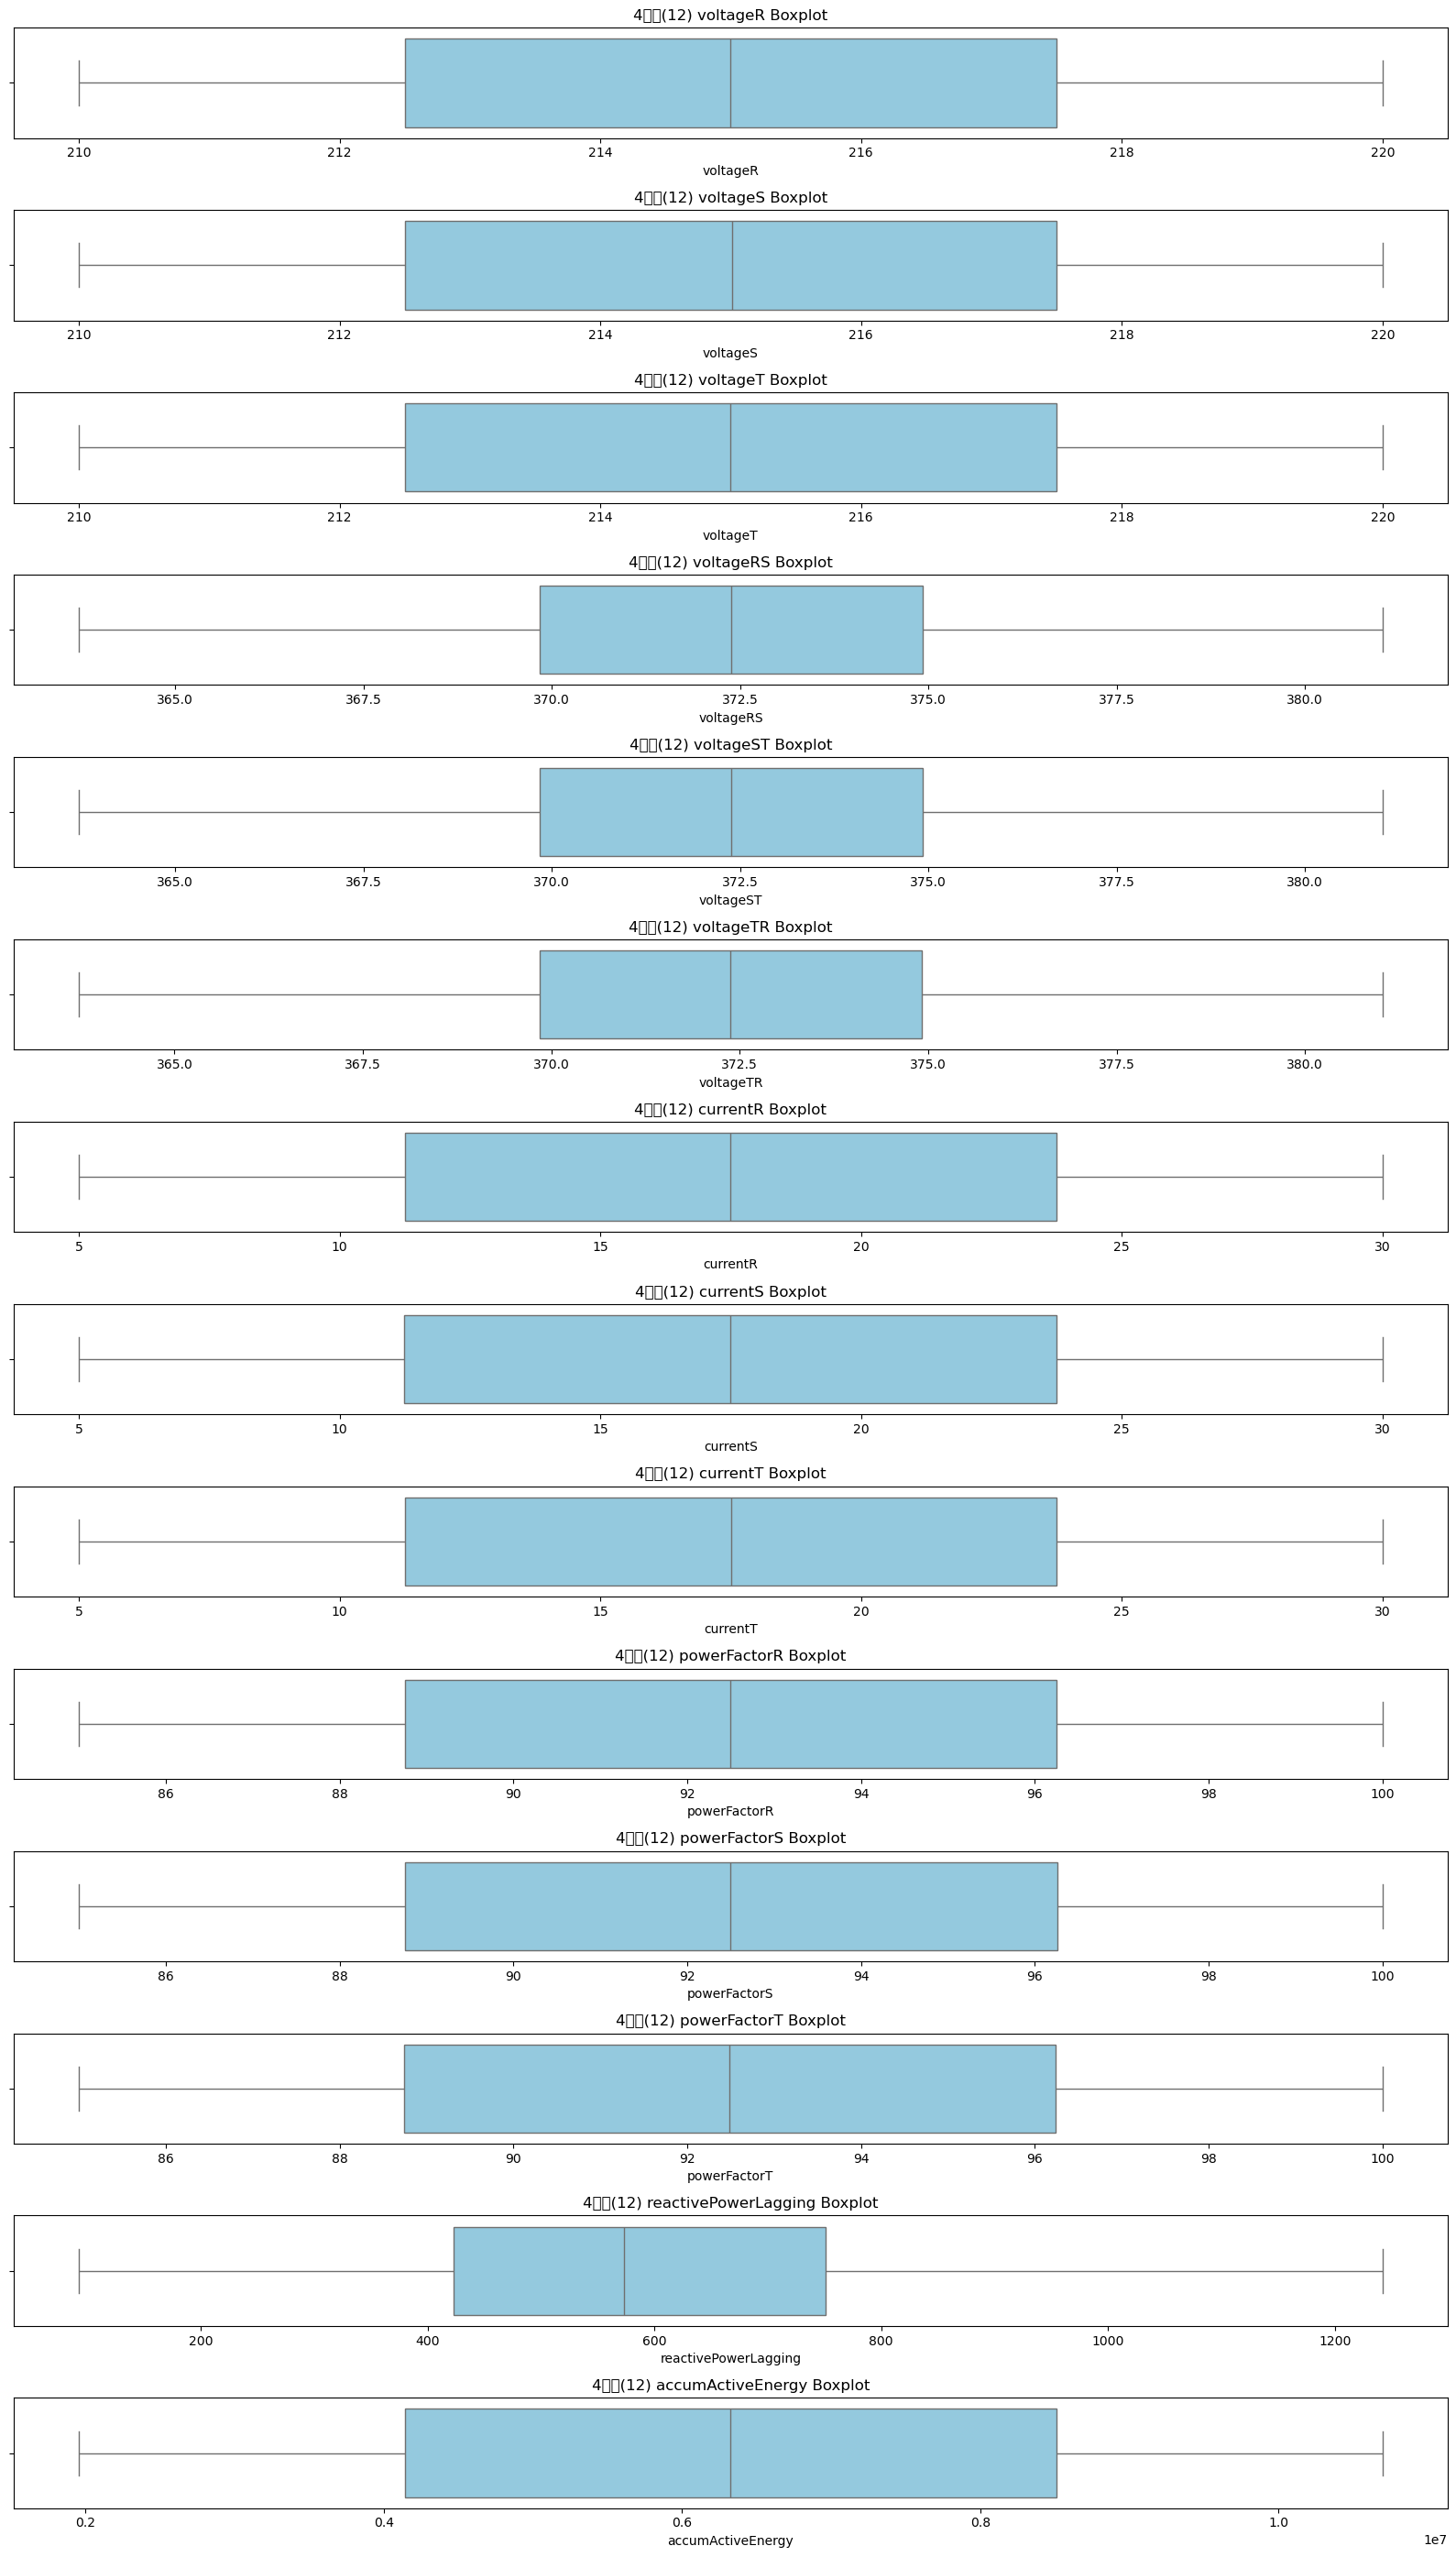

In [ ]:
# 주요 수치형 변수 리스트
num_cols = [
    'voltageR', 'voltageS', 'voltageT',
    'voltageRS', 'voltageST', 'voltageTR',
    'currentR', 'currentS', 'currentT',
    'powerFactorR', 'powerFactorS', 'powerFactorT',
    'reactivePowerLagging', 'accumActiveEnergy'
]

# 주요 수치형 변수별로 개별 박스플롯을 그리기
plt.figure(figsize=(16, 2 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=train_list[0][col], color='skyblue')
    plt.title(f'4호기(12) {col} Boxplot')
    plt.tight_layout()
plt.show()

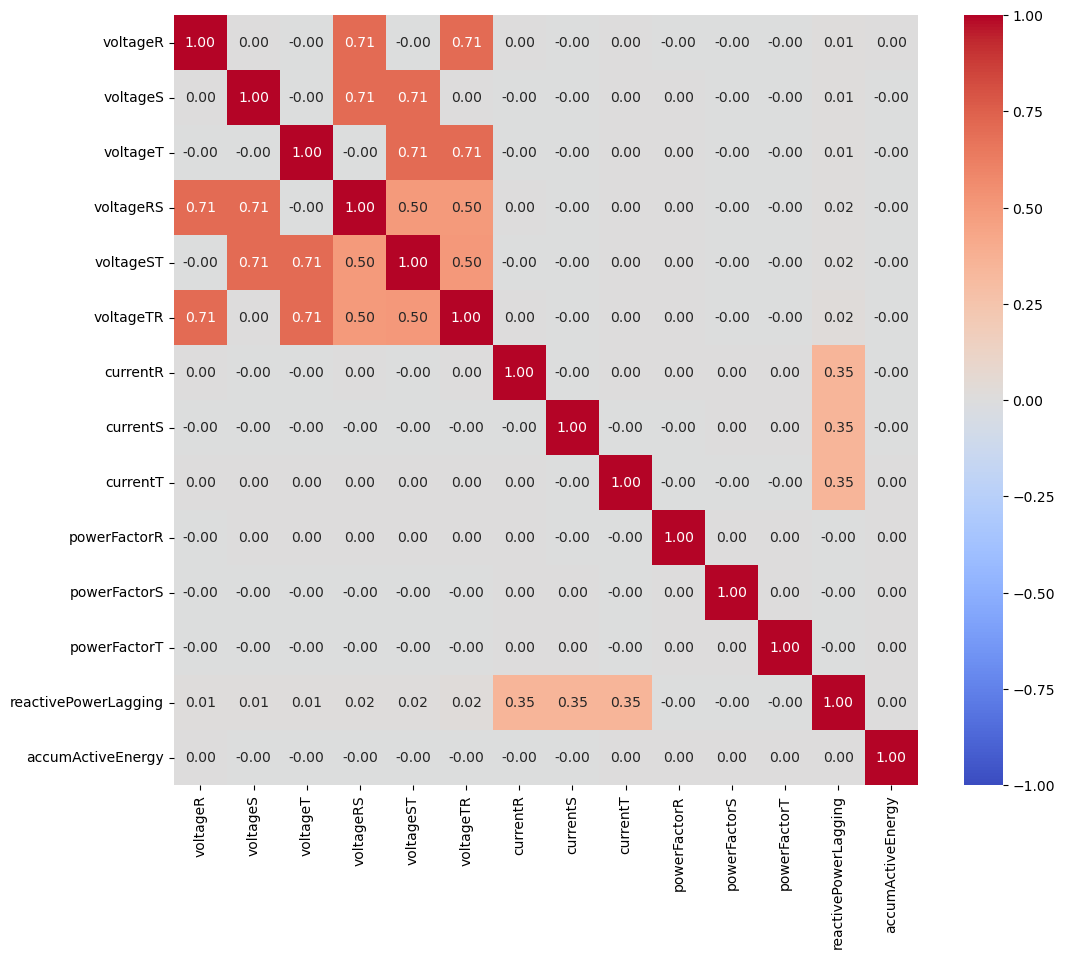

In [ ]:
# 전체체 주요 변수 간 상관관계 분석 및 시각화
corr = train_list[0][num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

C:\Users\hoyeong\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48

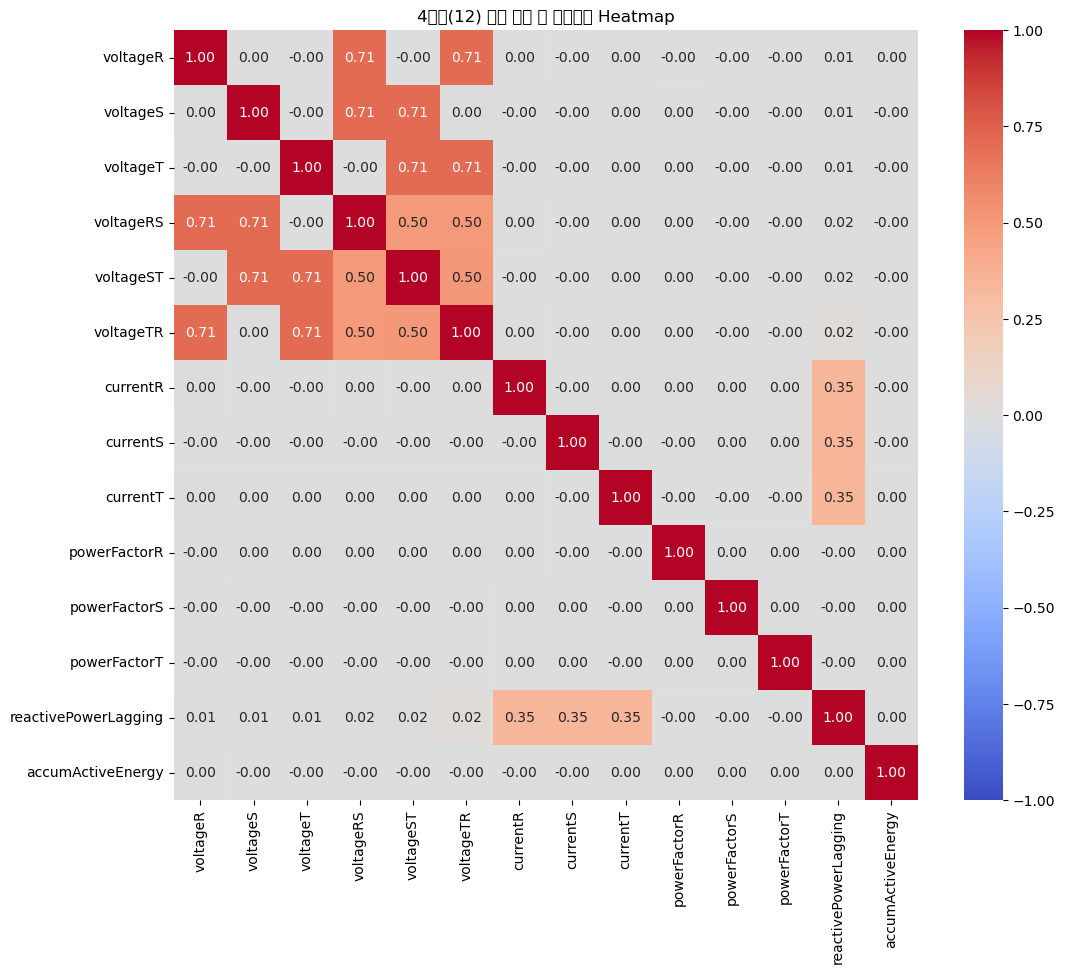

In [ ]:
# 4호기(12) 주요 변수 간 상관관계 분석 및 시각화
corr = train_list[0][num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("4호기(12) 주요 변수 간 상관관계 Heatmap")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    # 다중 공선성이 높은 칼럼 자동 추출 (VIF 기준 10 이상)
    vif_data = pd.DataFrame()
    vif_data["feature"] = num_cols
    vif_data["VIF"] = [variance_inflation_factor(df_4[num_cols].dropna().values, i) for i in range(len(num_cols))]
    high_vif_cols = vif_data[vif_data["VIF"] >= 10]["feature"].tolist()

    print("다중 공선성이 높은 칼럼:", high_vif_cols)
    return high_vif_cols

In [ ]:
# 다중 공선성이 높은 칼럼(PCA로 차원축소) 예시

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def pca_analysis(df,high_vif_cols):
    # 표준화
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[high_vif_cols])

    # PCA (설명분산 95%까지 유지)
    pca = PCA(n_components=0.95)
    pca_result = pca.fit_transform(scaled)

    print(f"PCA로 축소된 차원 수: {pca.n_components_}")
    # PCA 결과를 DataFrame으로 변환
    pca_df = pd.DataFrame(pca_result,
                          columns=[f'pca_{i+1}' for i in range(pca.n_components_)],
                          index=df[high_vif_cols].dropna().index)

    # VIF 낮은 칼럼만 따로 분리
    low_vif_cols = [col for col in df.columns if col not in high_vif_cols]
    df_low_vif = df[low_vif_cols].loc[df[high_vif_cols].dropna().index]

    # 낮은 VIF 칼럼 + PCA 주성분 결합
    df_final = pd.concat([df_low_vif.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)

    return df_final
    # # 주성분별 설명 분산 비율 시각화
    # plt.figure(figsize=(8,4))
    # plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    # plt.xlabel('Number of Components')
    # plt.ylabel('Cumulative Explained Variance')
    # plt.title('PCA - 누적 설명 분산 비율 (공선성 높은 변수)')
    # plt.grid(True)
    # plt.show()

In [ ]:
for i, df in enumerate(train_list):
    high_vif_cols = calculate_vif(df)
    df_pca  = pca_analysis(df, high_vif_cols)
    train_list[i] = df_pca 

for i, df in enumerate(test_list):
    high_vif_cols = calculate_vif(df)
    df_pca  = pca_analysis(df, high_vif_cols)
    test_list[i] = df_pca 

다중 공선성이 높은 칼럼: ['voltageR', 'voltageS', 'voltageT', 'voltageRS', 'voltageST', 'voltageTR', 'powerFactorR', 'powerFactorS', 'powerFactorT', 'reactivePowerLagging', 'accumActiveEnergy']
PCA로 축소된 차원 수: 8
다중 공선성이 높은 칼럼: ['voltageR', 'voltageS', 'voltageT', 'voltageRS', 'voltageST', 'voltageTR', 'powerFactorR', 'powerFactorS', 'powerFactorT', 'reactivePowerLagging', 'accumActiveEnergy']
PCA로 축소된 차원 수: 8
다중 공선성이 높은 칼럼: ['voltageR', 'voltageS', 'voltageT', 'voltageRS', 'voltageST', 'voltageTR', 'powerFactorR', 'powerFactorS', 'powerFactorT', 'reactivePowerLagging', 'accumActiveEnergy']
PCA로 축소된 차원 수: 8
다중 공선성이 높은 칼럼: ['voltageR', 'voltageS', 'voltageT', 'voltageRS', 'voltageST', 'voltageTR', 'powerFactorR', 'powerFactorS', 'powerFactorT', 'reactivePowerLagging', 'accumActiveEnergy']
PCA로 축소된 차원 수: 8
다중 공선성이 높은 칼럼: ['voltageR', 'voltageS', 'voltageT', 'voltageRS', 'voltageST', 'voltageTR', 'powerFactorR', 'powerFactorS', 'powerFactorT', 'reactivePowerLagging', 'accumActiveEnergy']
PCA로 축소된 차원 

In [ ]:
train_list[0].head()

,operation,currentR,currentS,currentT,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8
0,1,15.16,15.53,20.65,1.025959,1.565531,-0.423019,-1.183643,-1.556682,1.545287,-0.737732,-1.275237
1,1,25.70,7.07,19.75,-0.202362,1.745458,-1.211307,-1.551828,-0.754612,-1.745780,-0.611053,-0.520544
2,1,13.64,14.87,13.70,-1.127305,-1.490759,0.150148,-0.591138,-2.215586,-0.545653,-0.118533,-2.072373
3,1,25.76,26.35,5.80,-1.437079,1.338480,1.031138,-0.553607,-1.783799,-0.017045,-0.695548,-2.282873
4,1,8.65,29.49,15.09,1.294108,-0.319969,-0.014153,-0.919426,-0.994567,-0.295445,-1.044276,0.314655


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from lightgbm import LGBMRegressor

# ------------------------ 유틸 함수 정의 ------------------------

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
    return np.mean(diff) * 100

def stl_ml_forecast(train_ts, train_y, test_ts, period=288):
    train_ts = pd.to_datetime(train_ts)
    test_ts = pd.to_datetime(test_ts)

    stl = STL(train_y, period=period)
    result = stl.fit()
    trend, seasonal = result.trend, result.seasonal

    time_idx_train = ((train_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)
    time_idx_test = ((test_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)

    model_trend = LGBMRegressor(n_estimators=100, learning_rate=0.1,
                                 device='gpu', gpu_use_dp=False,
                                 tree_learner='serial', random_state=42)
    model_seasonal = LGBMRegressor(n_estimators=100, learning_rate=0.1,
                                    device='gpu', gpu_use_dp=False,
                                    tree_learner='serial', random_state=42)

    model_trend.fit(time_idx_train, trend)
    model_seasonal.fit(time_idx_train, seasonal)

    trend_pred = model_trend.predict(time_idx_test)
    seasonal_pred = model_seasonal.predict(time_idx_test)

    return trend_pred + seasonal_pred


In [ ]:
# ------------------------ 전체 실행 루프 ------------------------

results_all = []
lgbm_models = []
ts_all = []
y_all = []

for i in range(len(train_list)):
    print(f"\n========= Processing Dataset {i+1} =========")

    # 데이터 준비
    X_train_df = train_list[i]
    X_test_df = test_list[i]
    y_series = train_y[i].reset_index(drop=True)
    ts_series = pd.Series(train_timestamps[i]).reset_index(drop=True)
    ts_series = pd.to_datetime(ts_series)
    test_ts = pd.Series(test_timestamps[i]).reset_index(drop=True)
    test_ts = pd.to_datetime(test_ts)
    test_y_i = test_y[i].reset_index(drop=True)

    # STL 기반 예측
    stl_test_pred = stl_ml_forecast(ts_series, y_series, test_ts)

    # 전체 학습 데이터로 모델 훈련 (시간 index 기반)
    lgbm_model = LGBMRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        subsample=1.0,
        min_child_samples=10,
        device='gpu',
        gpu_use_dp=False,
        tree_learner='serial',
        random_state=42
    )
    time_idx_train = ((ts_series - ts_series.min()).astype('timedelta64[s]')).values.reshape(-1, 1)
    lgbm_model.fit(time_idx_train, y_series)

    lgbm_models.append(lgbm_model)
    ts_all.append(ts_series)
    y_all.append(y_series)

    # 테스트 예측
    voting_test_preds = lgbm_model.predict(((test_ts - ts_series.min()).astype('timedelta64[s]')).values.reshape(-1, 1))
    y_pred_test = (voting_test_preds * 0.3 + stl_test_pred * 0.7)

    # 평가 출력
    mae = mean_absolute_error(test_y_i, y_pred_test)
    rmse = mean_squared_error(test_y_i, y_pred_test, squared=False)
    smape_val = smape(test_y_i.values, y_pred_test)

    print(f"[Test Evaluation] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

    # 결과 저장
    test_results = pd.DataFrame({
        'Timestamp': test_ts,
        'Prediction': y_pred_test
    })
    results_all.append(test_results)



========= Processing Dataset 1 =========
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (7.98 MB) transferred to GPU in 0.006512 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 3010.249521
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] 

c:\Users\hoyeong\anaconda3\envs\lg_ai\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[Test Evaluation] MAE: 581.6645, RMSE: 716.0596, SMAPE: 19.85%

========= Processing Dataset 2 =========
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (7.98 MB) transferred to GPU in 0.005855 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 3009.839070
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bin

c:\Users\hoyeong\anaconda3\envs\lg_ai\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[Test Evaluation] MAE: 582.8692, RMSE: 717.5136, SMAPE: 19.90%

========= Processing Dataset 3 =========
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (7.98 MB) transferred to GPU in 0.006411 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 3009.553139
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bin

...

c:\Users\hoyeong\anaconda3\envs\lg_ai\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[Test Evaluation] MAE: 581.9746, RMSE: 716.5364, SMAPE: 19.88%

========= Processing Dataset 12 =========
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (7.98 MB) transferred to GPU in 0.006508 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 3010.273638
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bi

c:\Users\hoyeong\anaconda3\envs\lg_ai\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[Test Evaluation] MAE: 582.4920, RMSE: 716.8754, SMAPE: 19.89%

========= Processing Dataset 13 =========
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1 dense feature groups (7.98 MB) transferred to GPU in 0.006357 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 3010.160937
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 2090880, number of used features: 1
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3080, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bi

c:\Users\hoyeong\anaconda3\envs\lg_ai\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# ------------------------ 향후 5월 예측 (통합 버전) ------------------------

from datetime import datetime

# 예측할 시간 생성: 2025년 5월 1일부터 5월 28일, 1시간 단위
future_ts = pd.date_range(start="2025-05-01 00:00:00", end="2025-05-28 23:00:00", freq="1H")
future_ts = pd.to_datetime(future_ts)

# STL + LGBM 예측 결과 저장 리스트
stl_preds_all = []
lgbm_preds_all = []

for i in range(len(lgbm_models)):
    print(f"📈 Predicting with Model {i+1}")

    # STL 기반 예측
    stl_pred = stl_ml_forecast(ts_all[i], y_all[i], future_ts)
    stl_preds_all.append(stl_pred)

    # LGBM 기반 예측
    time_idx_future = (pd.to_datetime(future_ts) - ts_all[i].min()).total_seconds().reshape(-1, 1)
    
    lgbm_pred = lgbm_models[i].predict(time_idx_future)
    lgbm_preds_all.append(lgbm_pred)

# ------------------------ 최종 예측 결합 ------------------------

# numpy로 변환
stl_preds_all = np.array(stl_preds_all)   # (13, 672)
lgbm_preds_all = np.array(lgbm_preds_all) # (13, 672)




In [ ]:
# 가중 평균 (LGBM 30%, STL 70%)
final_preds = (lgbm_preds_all * 0.3 + stl_preds_all * 0.7).mean(axis=0)

agg_pow = final_preds * 672
may_bill = agg_pow * 180
may_carbon = agg_pow * 0.424

forecast_df = pd.DataFrame({
    'id': future_ts,
    'hourly_pow': final_preds,
    'agg_pow': agg_pow,
    'may_bill': may_bill,
    'may_carbon': may_carbon
})

# 👉 datetime을 문자열 포맷으로 바꿔 저장
forecast_df['id'] = forecast_df['id'].dt.strftime('%Y-%m-%d %H:%M:%S')

# 저장
forecast_df.to_csv("forecast_may2025_ensemble.csv", index=False)
